Mobile Price classification dataset ML model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.DataFrame(pd.read_csv("/content/sample_data/train.csv"))
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


initial data checks for cleaning

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [3]:
df.duplicated().sum()

np.int64(0)

checking data distribution

In [4]:
df['price_range'].value_counts().sort_index()

,count
price_range,
0,500
1,500
2,500
3,500


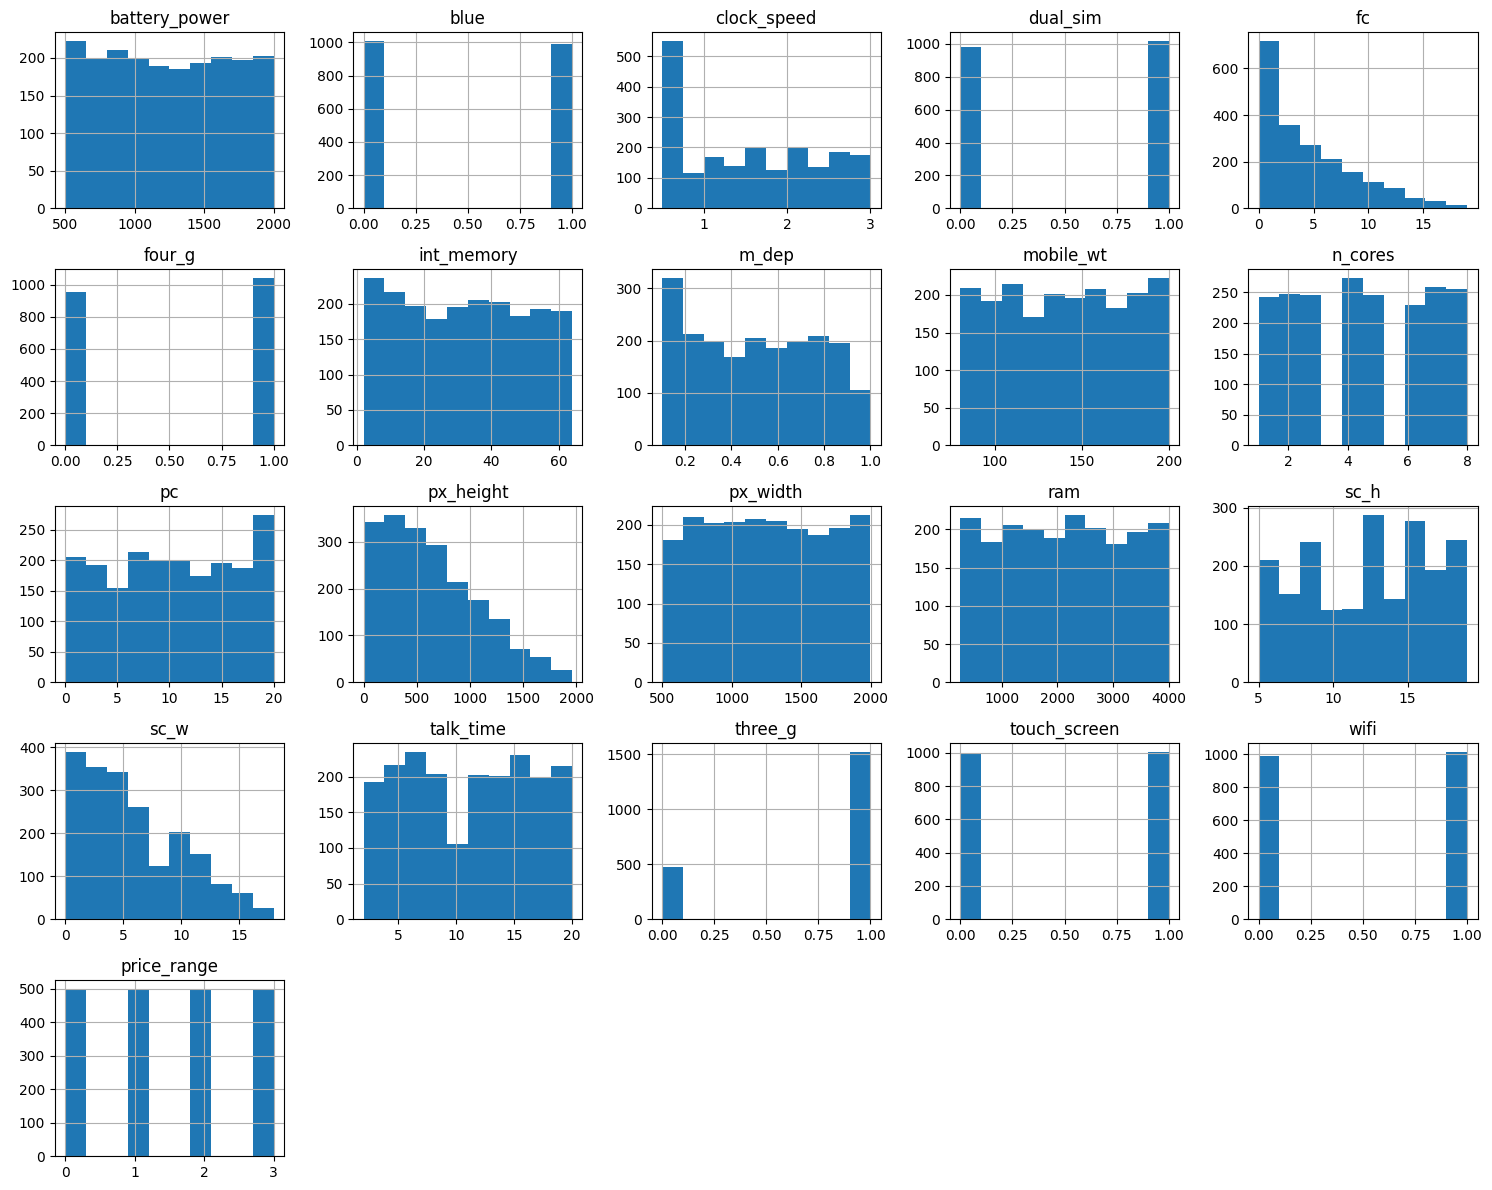

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

In [6]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


checking pearson correlation

In [7]:
df.corr()['price_range'].sort_values()

,price_range
touch_screen,-0.030411
mobile_wt,-0.030302
clock_speed,-0.006606
m_dep,0.000853
n_cores,0.004399
four_g,0.014772
dual_sim,0.017444
wifi,0.018785
blue,0.020573
talk_time,0.021859


checking correlation - RAM has the most correlation

In [8]:
df.groupby('price_range').mean()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
price_range,,,,,,,,,,,,,,,,,,,,
0,1116.902,0.486,1.5502,0.500,4.084,0.518,31.174,0.4902,140.552,4.600,9.574,536.408,1150.270,785.314,12.324,5.682,10.612,0.746,0.524,0.496
1,1228.868,0.490,1.4886,0.510,4.340,0.524,32.116,0.5240,140.510,4.298,9.924,666.892,1251.908,1679.490,12.212,5.544,11.362,0.756,0.522,0.504
2,1228.320,0.486,1.5298,0.498,4.498,0.494,30.920,0.4908,143.614,4.682,10.018,632.284,1234.046,2582.816,12.010,5.714,10.972,0.774,0.470,0.504
3,1379.984,0.518,1.5204,0.530,4.316,0.550,33.976,0.5020,136.320,4.502,10.150,744.848,1369.838,3449.232,12.680,6.128,11.098,0.770,0.496,0.524


Checking if RAM's correlation is accurate - no


---



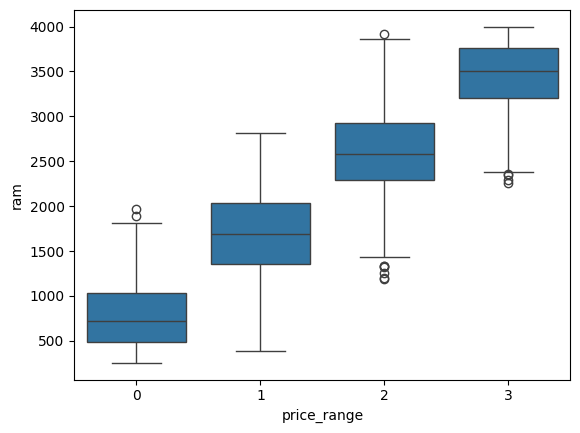

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='price_range', y='ram')
plt.show()

In [10]:
df.corr(method='spearman')['price_range'].sort_values()

,price_range
touch_screen,-0.030411
mobile_wt,-0.030214
clock_speed,-0.005436
m_dep,-0.000322
n_cores,0.004651
four_g,0.014772
dual_sim,0.017444
wifi,0.018785
blue,0.020573
talk_time,0.022138


train_test_split


In [11]:
X = df.drop('price_range', axis=1)
y= df['price_range']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)



Baseline model search - Logistic Regression

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



Comparison of Logistic regression and random forest classifier - Logistic regression accuracy 0.965, random forest classifier accuracy 0.8775, logistic regression wins

In [13]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.8775
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.81      0.84      0.82       100
           2       0.82      0.79      0.81       100
           3       0.94      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



checking how logistic regression or Softmax regression/Multinomial regression works.

In [14]:
lr.predict_proba(X_test.iloc[:5])

array([[1.68652258e-18, 8.79428268e-10, 3.59623221e-04, 9.99640376e-01],
       [5.29048485e-03, 7.04970815e-01, 2.89402554e-01, 3.36145407e-04],
       [9.98062613e-01, 1.93736941e-03, 1.72508309e-08, 2.29654848e-16],
       [2.80724635e-04, 3.75900669e-01, 6.21861872e-01, 1.95673486e-03],
       [8.66301774e-16, 1.28762595e-07, 5.33899683e-03, 9.94660874e-01]])

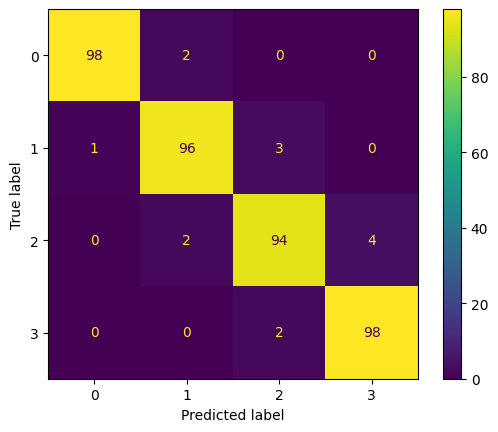

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

I need to check if RAM is the only big force carrying the logistic regression results - thankfully no, otherwise it would be boring. in RAM vs price range, accurancy is 0.755

In [16]:
X_ram = df[['ram']]
y = df['price_range']

X_train_ram, X_test_ram, y_train_ram, y_test_ram = train_test_split(
    X_ram, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr_ram = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

lr_ram.fit(X_train_ram, y_train_ram)

print(accuracy_score(
    y_test_ram,
    lr_ram.predict(X_test_ram)
))


0.755


I need to see which all features are important to Logistic regression model. as a result, ram, battery and phone dimesions are way more important.

In [17]:
coef = lr.named_steps['model'].coef_

feature_importance = pd.DataFrame(
    np.abs(coef).mean(axis=0),
    index=X.columns,
    columns=['importance']
).sort_values('importance', ascending=False)
feature_importance

,importance
ram,7.147931
battery_power,1.782751
px_width,1.048843
px_height,1.015026
mobile_wt,0.306240
int_memory,0.126567
wifi,0.124381
sc_h,0.100494
four_g,0.076720
dual_sim,0.075064


now, I am going to check if the top 4 features are more important than all 20 features. Accuracy 0.9675!!

In [18]:
top_features = [
    'ram',
    'battery_power',
    'px_width',
    'px_height'
]

X_top = df[top_features]
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top, y, test_size = 0.2, random_state = 42, stratify=y)
lr_top = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
lr_top.fit(X_train_top, y_train_top)
print(accuracy_score(y_test_top, lr_top.predict(X_test_top)))

0.9675


Considering the the accuracy score of 0.965, more than top 20 features', I need to verify the claim using CV. And cross validation certainly exposed that my claim was true and 0.965 accuracy score is only for that train_test distribution.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_top = cross_val_score(
    lr_top,
    X_top,
    y,
    cv=cv,
    scoring='accuracy'
)

scores_all = cross_val_score(
    lr,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Top 4:", scores_top)
print("Top 4 mean:", scores_top.mean())

print("All features:", scores_all)
print("All features mean:", scores_all.mean())

Top 4: [0.96   0.975  0.9525 0.9475 0.9525]
Top 4 mean: 0.9574999999999999
All features: [0.9625 0.965  0.9575 0.9575 0.9625]
All features mean: 0.961


In [20]:
df['screen_area'] = df['px_height'] * df['px_width']


In [22]:
X_top_1 = df.drop('price_range', axis=1)
y = df['price_range']
lr_top_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
scores_top_1 = cross_val_score(
    lr_top_1,
    X_top_1,
    y,
    cv=cv,
    scoring='accuracy'
)
print(scores_top_1)
print(scores_top_1.mean())

[0.9625 0.9625 0.9575 0.955  0.955 ]
0.9585000000000001


In [24]:
df['screen_ratio'] = np.where(df['px_height'] == 0, 0, df['px_width'] / df['px_height'])
X_top_2 = df.drop(['price_range','screen_area'], axis=1)
y = df['price_range']
lr_top_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
scores_top_2 = cross_val_score(
    lr_top_2,
    X_top_2,
    y,
    cv=cv,
    scoring='accuracy'
)
print(scores_top_2)
print(scores_top_2.mean())

[0.9625 0.965  0.955  0.9575 0.9625]
0.9605


In [25]:
from sklearn.svm import SVC

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

scores_svm = cross_val_score(
    svm,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print(scores_svm)
print(scores_svm.mean())

[0.8675 0.8875 0.86   0.86   0.91  ]
0.877


In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

scores_knn = cross_val_score(
    knn,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print(scores_knn)
print(scores_knn.mean())

[0.52   0.535  0.4825 0.5075 0.515 ]
0.512


In [27]:
scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print(scores_rf)
print(scores_rf.mean())

[0.885  0.91   0.8725 0.86   0.895 ]
0.8844999999999998


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [100, 1000, 10000, 100000],
    'model__solver': ['lbfgs', 'newton-cg', 'newton-cholesky']
}

grid = GridSearchCV(
    lr,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'model__C': 1000, 'model__solver': 'newton-cg'}
Best CV score: 0.9734999999999999


In [31]:
best_lr = grid.best_estimator_

best_lr.fit(X_train, y_train)

y_pred_final = best_lr.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Test accuracy: 0.9725
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.97      0.97      0.97       100
           2       0.95      0.96      0.96       100
           3       0.98      0.97      0.97       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



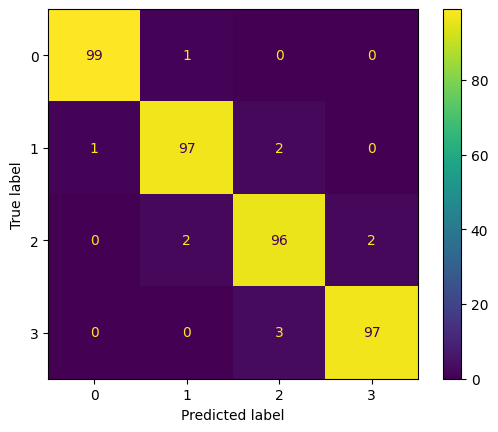

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final
)

plt.show()

In [33]:
final_model = best_lr.named_steps['model']

coef = final_model.coef_

feature_importance = pd.DataFrame(
    np.abs(coef).mean(axis=0),
    index=X.columns,
    columns=['importance']
).sort_values(
    'importance',
    ascending=False
)

print(feature_importance)

               importance
ram             62.600933
battery_power   15.764858
px_width         9.253185
px_height        9.207863
mobile_wt        2.507907
int_memory       1.122443
wifi             0.906086
n_cores          0.903986
pc               0.715510
sc_h             0.493236
blue             0.390751
dual_sim         0.375171
clock_speed      0.249691
fc               0.247718
four_g           0.220137
talk_time        0.217474
three_g          0.130646
sc_w             0.118027
m_dep            0.102417
touch_screen     0.067580


In [ ]:
import joblib

joblib.dump(best_lr, "mobile_price_model.pkl")